# **Predicting Heart Disease using Machine Learning**


> This notebook looks into various Python-based machine learning and data science libraries in an attempt to build a machine learning model capable of predicting whether or not a person has a **heart disease** based on their **medical attributes**.

---

**We're going to take the following approch:**
1. Problem Defination
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

---

<div style="background:#ffffff; padding:12px; text-align:center;">
  <img src="./assets/images/6%20Step%20Machine%20Learning%20Modelling%20Framework.png" alt="6 Step Machine Learning Modelling Framework" style="max-width:100%; height:auto; width:auto;" />
</div>

<p align="center"><strong>6 Step Machine Learning Modelling Framework</strong></p>

![](./assets/images/step%20of%20the%20machine%20learning%20modelling%20process.png)

## **1. Problem Defination**

In a statement,
> Given clinical parameters about a patient, can we predict whether or not a person has heart disease?

## **2. Data**

- The [original data](./dataset/heart-disease.csv) came from the Cleavland data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/45/heart+disease).

- There is also a [extented version](./dataset/heart_disease_uci.csv) available on [kaggle](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data). 

## **3. Evaluation**

> If we can reach 95% at predicting whether or not a person has a heart disease during the proof of concept. we'll pusue the project.

## **4. Features**

This is where you'll get the different information about each of the features in your data.

<div style="padding:12px 14px; border-left:4px solid #60a5fa; background:#111827; border-radius:10px; color:#e5e7eb;">
Think of this section as the <strong>data dictionary</strong>. Each row is one clue the model can use to learn patterns.
</div>

**Below is the Data Dictionary:**

| Feature  | Description | Example Values |
|:-----|:-----|:------|
| **age** | Age in years | 29, 45, 60 |
| **sex** | 1 = male; 0 = female | 0, 1 |
| **cp** | Chest pain type | 0: Typical angina, 1: Atypical angina, 2: Non-anginal pain, 3: Asymptomatic |
| **trestbps** | Resting blood pressure in mm Hg | 120, 140, 150 |
| **chol** | Serum cholesterol in mg/dl | 180, 220, 250 |
| **fbs** | Fasting blood sugar > 120 mg/dl (1 = true; 0 = false) | 0, 1 |
| **restecg** | Resting electrocardiographic results | 0: Nothing to note, 1: ST-T wave abnormality, 2: Left ventricular hypertrophy |
| **thalach** | Maximum heart rate achieved | 160, 180, 190 |
| **exang** | Exercise induced angina (1 = yes; 0 = no) | 0, 1 |
| **oldpeak** | ST depression induced by exercise relative to rest | 0.5, 1.0, 2.0 |
| **slope** | Slope of the peak exercise ST segment | 0: Upsloping, 1: Flat, 2: Downsloping |
| **ca** | Number of major vessels colored by fluoroscopy | 0, 1, 2, 3 |
| **thal** | Thalium stress result | 1: Normal, 3: Normal, 6: Fixed defect, 7: Reversible defect |
| **target** | Has disease or not (1 = yes; 0 = no) | 0, 1 |

---

<div style="padding:10px 12px; border-radius:10px; background:#0f172a; border:1px solid #334155; color:#cbd5e1;">
<strong style="color:#93c5fd;">Small tip:</strong> The model learns from patterns across all these features together, not from just one row by itself.
</div>

---
- **14 Features in total**
> **Note:** No personal identifiable information (PPI) can be found in the dataset.

## **Preparing the tools**

We're are going to use **Pandas**. **Numpy** and **Matplotlib** for data analysis and manipluation.

In [58]:
# import all the tools we need

# Regular EDA (exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# We want our plots to appear inside the notebook
%matplotlib inline  

# Models from Scikit-Learn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

## **Load Data**

In [59]:
df = pd.read_csv("./dataset/heart-disease.csv")
df.shape # (Rows, Columns)

(303, 14)

## **Data Explorartion or EDA (Exploratory Data Analysis)**

> The goal here is to find more about the data and become a subject matter expert on the dataset you are working with.

1. What question(s) are you trying to solve?
2. What kind of data do we have and how to treat different types?
3. What's missing from the data and how do you deal with it?
4. Where are the outliers and why should you care about them ?

<details>
  <summary><strong>Outlier</strong></summary>

An <strong>outlier</strong> is a data point that is much higher or lower than most other values.

Think of a classroom where most students are 18-22 years old, but one value says 85. That unusual value is an outlier.

Why it matters:
- It can be a real rare case (important signal).
- It can be a data entry or measurement error.
- It can affect model training and pull results in the wrong direction.

Simple check methods: boxplot, histogram, and IQR rule.
</details>

5. How can you add, change or remove features to get more out of your data?

In [60]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [61]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [62]:
# Let's find out how many each of the class are there
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

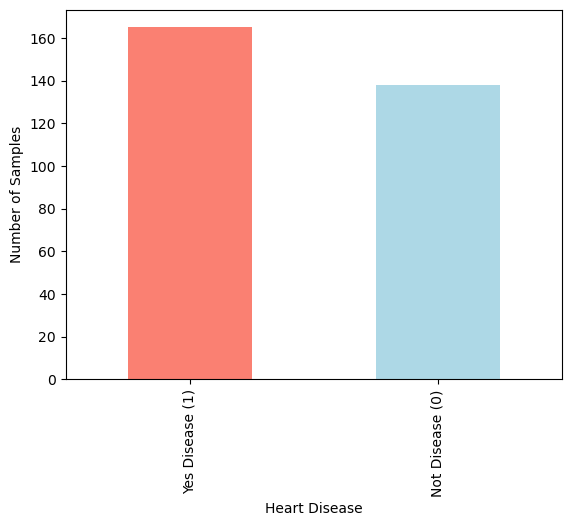

In [63]:
df['target'].value_counts().plot(kind="bar",
                                 color=["salmon", "lightblue"],
                                 xlabel="Heart Disease",
                                 ylabel="Number of Samples");
plt.xticks([0, 1], ["Yes Disease (1)", "Not Disease (0)"]);

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [65]:
# Are there any missing values?
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [66]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### **Heart Disease Frequency according to Sex**
- For sex:
  - 1 = male 
  - 0 = female

In [67]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

**So Males > Females**

In [68]:
# Comapare Target Column with Sex column
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


**So like we get a intuation that:**
- **roughly `~75%` (72/96) of woman taking part in the test has Heart-Disease**

- **And roughly `~45%` (93/207) of man taking part in the test has Heart-Disease**

- **roughly `~54%` (165/303) of people taking part in the test has Heart-Disease**

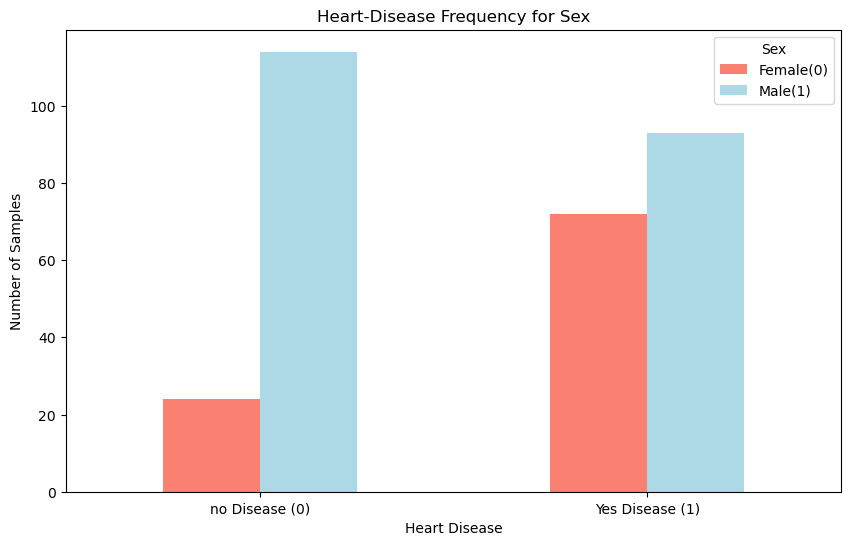

In [69]:
# Create a plot of cross-tab
pd.crosstab(df.target, df.sex).plot(kind="bar",
                                    figsize=(10,6),
                                    color=["salmon", "lightblue"],
                                    xlabel="Heart Disease",
                                    ylabel="Number of Samples")
plt.title("Heart-Disease Frequency for Sex")
plt.xticks([0,1], ["no Disease (0)", "Yes Disease (1)"], rotation=0)
plt.legend(["Female(0)", "Male(1)"], title="Sex");

### **Age Vs. Maximum heart rate for `Heart Disease`**

In [70]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [71]:
# Thalach = Max. heart rate achieved
df["thalach"].value_counts()


thalach
162    11
163     9
160     9
173     8
152     8
       ..
117     1
71      1
118     1
134     1
90      1
Name: count, Length: 91, dtype: int64

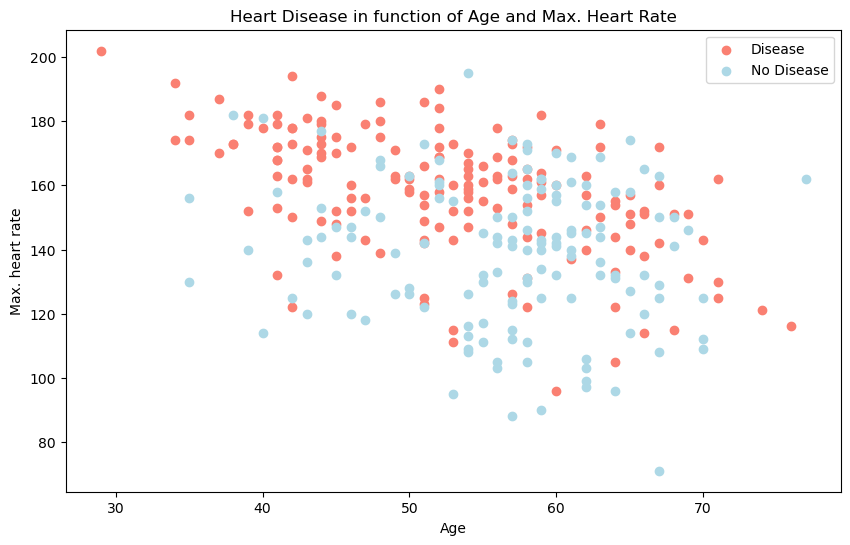

In [72]:
# Create another figure
plt.figure(figsize=(10, 6))

# Scatter with positive Examples
plt.scatter(df.age[df.target==1],
            df.thalach[df.target==1],
            c="salmon")

# Scatter with negative examples
plt.scatter(df.age[df.target==0],
            df.thalach[df.target==0],
            c="lightblue")

# Add some helpful info
plt.title("Heart Disease in function of Age and Max. Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max. heart rate")
plt.legend(["Disease", "No Disease"]);

**Here we cannot get some pattern at a sight or you can say intuiation so from here our machine learning model will take**

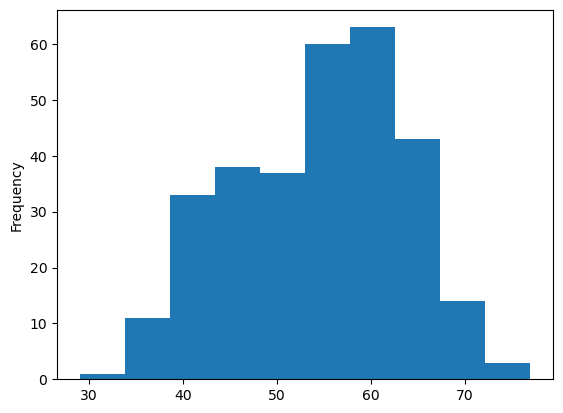

In [73]:
# Check the distribution of the age column with a histogram
df['age'].plot.hist();

**We can see it's a [normal distribution](https://en.wikipedia.org/wiki/Normal_distribution) but slightly swaying to the right, which reflects in the scatter plot above**

### **Heart Disease Frequency per Chest Pain type**

`cp`: **chest pain type**
- `0`: **Typical angina**: chest pain related decrease blood supply to the heart
- `1`: **Atypical angina**: chest pain not related to heart
- `2`: **Non-anginal pain**: typically esophageal spasms (non heart related)
- `3`: **Asymptomatic**: chest pain not showing signs of disease

In [74]:
df["cp"].value_counts()

cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64

In [75]:
pd.crosstab(df.cp,
            df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


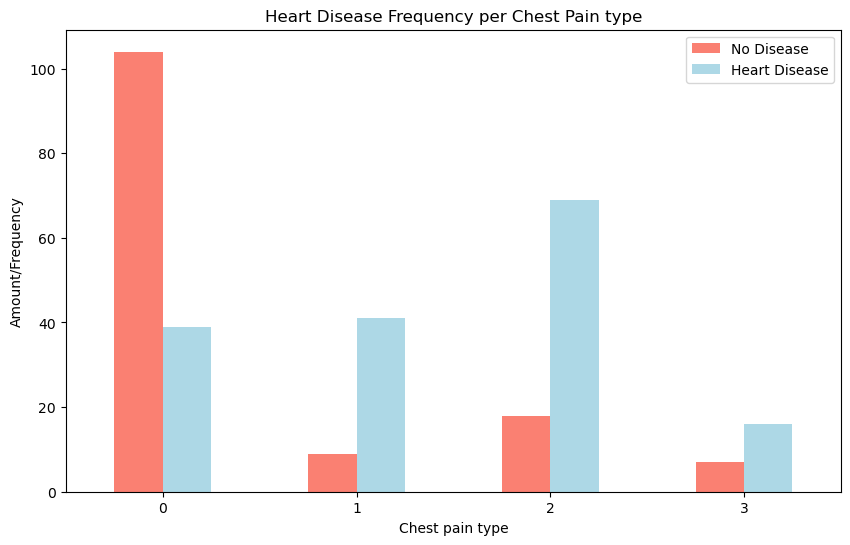

In [76]:
# Make the crosstab more visual
pd.crosstab(df.cp, df.target).plot(kind='bar',
                                   figsize=(10,6),
                                   color=['salmon','lightblue'])

# Add some communication
plt.title("Heart Disease Frequency per Chest Pain type")
plt.xlabel("Chest pain type")
plt.ylabel("Amount/Frequency")
plt.legend(["No Disease", "Heart Disease"])
plt.xticks(rotation=0);

In [77]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### **Correlation between Independent varibales**

A **correlation matrix** is a table that shows how strongly every numeric column is related to every other numeric column.

- Each value is between **−1 and +1**
  - `+1`: perfect positive relation. When one increases, the other also increases.

  - `0`: no linear relation. No clear straight-line relationship.
  
  - `−1`: perfect negative relation. When one increases, the other decreases.

> Here quickly finding which features are related to our target

In [78]:
# Find the correlation between our independent variables
corr_matrix = df.corr()
corr_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


(14.0, -0.5)

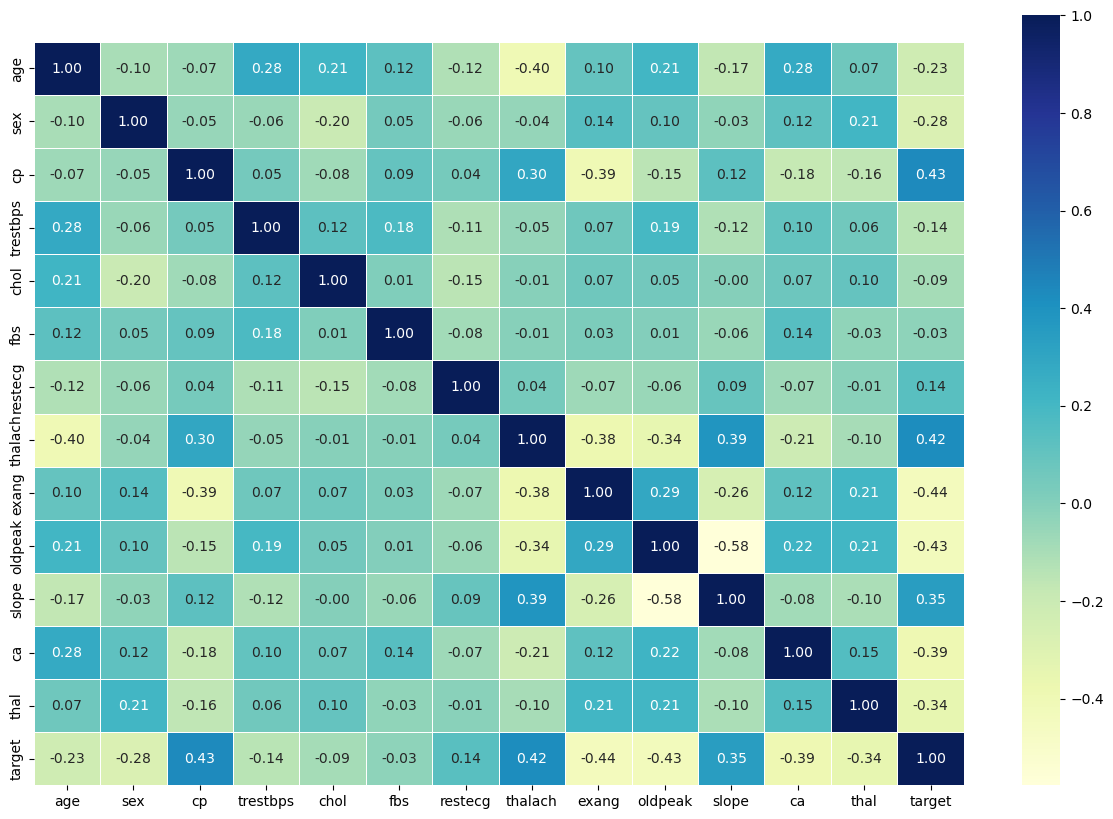

In [79]:
# Lets make a correlational metrix little prettier
fig, ax = plt.subplots(figsize=(15, 10))
ax = sns.heatmap(corr_matrix,
                 annot=True,
                 linewidths=0.5,
                 fmt=".2f",
                 cmap="YlGnBu");

# Read the current y-axis limits from the plot (bottom and top values).
bottom, top = ax.get_ylim()
# Set the y-axis again, but lower the top a little (by 0.5) to align the heatmap display.
ax.set_ylim(bottom, top - 0.5)

## **5. Modelling**

In [80]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [81]:
# Split data into X and y
X = df.drop('target', axis=1)
y = df["target"]

In [82]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [83]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [84]:
# Split data into Train and Test sets
np.random.seed(42)

# Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2)

In [85]:
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
270,46,1,0,120,249,0,0,144,0,0.8,2,0,3


In [86]:
y_train, len(y_train)

(132    1
 202    0
 196    0
 75     1
 176    0
       ..
 188    0
 71     1
 106    1
 270    0
 102    1
 Name: target, Length: 242, dtype: int64,
 242)

**Now we got our data into `Training` and `Test` sets, it's time to build a machine learning model.**

We'll train it (find the patterns) on the **Training set.**

And we'll test it (use the patterns) on the **Test set.**

---

![Model Selection Map](./assets/images/sklearn-ml-map.png)

**We're going to try 3 different Machine learning models:**
1. [Logestic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
2. [K-Nearest Neighbour Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier)
3. [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier)

In [87]:
# Put Models in a Dictionary 
models = {"Logestic Regression" : LogisticRegression(max_iter=1070), # Note: if you see a warning about "convergence not reached", you can increase `max_iter` until convergence is reached  
          "KNN" : KNeighborsClassifier(),
          "Random Forest" : RandomForestClassifier()}

# Create a Function to fit and score models

def fit_and_score(models, X_train, X_test, y_train, y_test) -> dict:
    """
    Fit and evaluates given machine learning models.
    models: a dict of different Scikit-Learn machine learning models
    X_train: Training data (no labels)
    X_test: Testing data (no labels)
    y_train: Training labels
    y_test: Test labels
    """
    
    # Set random seed(42)
    np.random.seed(42)
    
    # Make a dictionary to keep model scores
    models_scores = {}
    
    # Loop through models
    for name, model in models.items():
        # Fit the model to data
        model.fit(X_train, y_train)
        # Evaluate the model and append its score to models_scores
        models_scores[name] = model.score(X_test, y_test)
        
        
    return models_scores

In [88]:
models_scores = fit_and_score(models=models,
                              X_train=X_train,
                              X_test=X_test,
                              y_train=y_train,
                              y_test=y_test)
# Baseline Scores
models_scores

{'Logestic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

### **Model Comparison**

In [89]:
models_compare = pd.DataFrame(models_scores,
                              index=["Accuracy"])
models_compare

,Logestic Regression,KNN,Random Forest
Accuracy,0.885246,0.688525,0.836066


In [90]:
models_compare.T

,Accuracy
Logestic Regression,0.885246
KNN,0.688525
Random Forest,0.836066


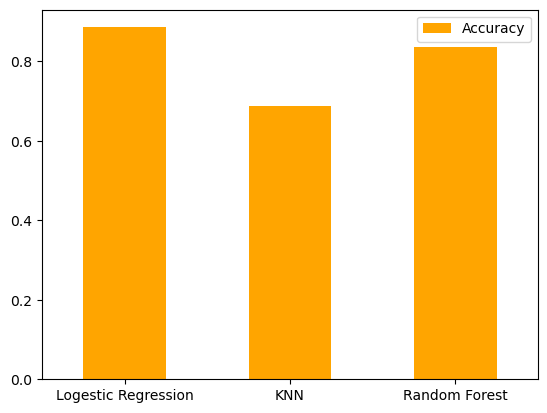

In [91]:
models_compare.T.plot.bar(color="orange")
plt.xticks(rotation=0);

**From the plot it looks like the [sklearn.linear_model.LogisticRegression()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) model performs best.**

---

**Now we have a baseline model. Since first model results are usually not final, our next step is to improve and evaluate it further. What should we do ?**

**Let's look at the following:**
- Hyperparameter tuning 
- Feature Importance
- Confusion Matrix
- Cross-validation
- Precison
- Recall
- F1-score
- Classification Report
- ROC (Receiver Operating Characteristic) curve
- Area Under the Curve (AUC)

### **Hypermarameter Tuning of KNN (By hand)**

In [92]:
# Let's tune KNN

train_scores = []
test_scores = []

# Let's setup random seed
np.random.seed(42)

# Create a list of different values for n_neighbors
neighbors = range(1, 21)

# Setup KNN instance
knn = KNeighborsClassifier()

# Loop through different n_neighbors
for i in neighbors:
    knn.set_params(n_neighbors=i)
    
    # Fit the estimator
    knn.fit(X_train, y_train)
    
    # Update the training scores
    train_scores.append(knn.score(X_train, y_train))
    
    # Update the Testing scores
    test_scores.append(knn.score(X_test, y_test))

In [93]:
train_scores

[1.0,
 0.8099173553719008,
 0.7727272727272727,
 0.743801652892562,
 0.7603305785123967,
 0.7520661157024794,
 0.743801652892562,
 0.7231404958677686,
 0.71900826446281,
 0.6942148760330579,
 0.7272727272727273,
 0.6983471074380165,
 0.6900826446280992,
 0.6942148760330579,
 0.6859504132231405,
 0.6735537190082644,
 0.6859504132231405,
 0.6652892561983471,
 0.6818181818181818,
 0.6694214876033058]

In [94]:
test_scores

[0.6229508196721312,
 0.639344262295082,
 0.6557377049180327,
 0.6721311475409836,
 0.6885245901639344,
 0.7213114754098361,
 0.7049180327868853,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.7540983606557377,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.6885245901639344,
 0.7213114754098361,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.6557377049180327]

Maximum KNN score on test data: 75.41%
Best n_neighbors : 11


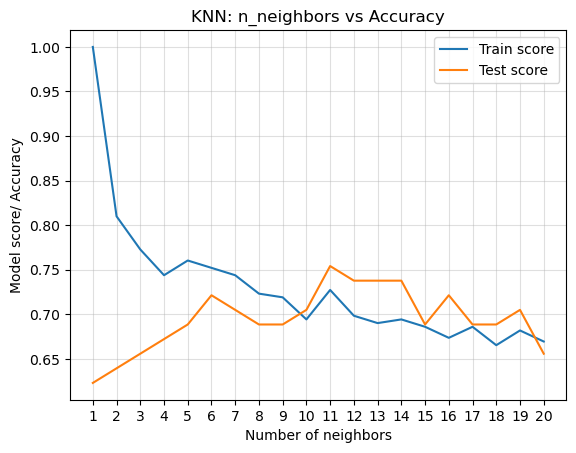

In [95]:
plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")
plt.title("KNN: n_neighbors vs Accuracy")
plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Number of neighbors")
plt.ylabel("Model score/ Accuracy")
plt.grid(True, alpha=0.4)
plt.legend()

# Find the best value
best_n = neighbors[test_scores.index(max(test_scores))]
print(f"Maximum KNN score on test data: {max(test_scores)*100:.2f}%")
print(f"Best n_neighbors : {best_n}")

Looking at the graph, `n_neighbors = 11` seems best.

Even knowing this, the `KNN`'s model performance didn't get near what `LogisticRegression` or the `RandomForestClassifier` did.

Because of this, we'll discard `KNN` and focus on the other two.

---

### **Hyperparameter tuning with `RandomizedSearchCV`**

We're going to tune:
- [LogisticRegression()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
- [RandomForestClassifier()](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier)

...using `RandomizedSearchCV` & `Cross-validation`

In [96]:
# Create a hyperparameter grid for logistic Regression
log_reg_grid = {"C" : np.logspace(-4, 4, 20),
                "solver": ["liblinear"],
                "max_iter": [300, 1000, 3000, 10000]}

# Create a hyperparameter grid for RandomForestClassifier
rf_grid = {"n_estimators" : np.arange(10, 1000, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(1, 20, 2)}

```python
np.logspace(start, stop, num)
               ↓       ↓
           10^start  10^stop
```

In [97]:
np.logspace(-4, 4, 20)

# Part	Meaning
# -4	Start at 10^−4 = 0.0001
#  4    End at 10^4 = 10,000
# 20	Create 20 evenly spaced values in log scale

array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04])

In [98]:
np.arange(10, 1000, 50)

array([ 10,  60, 110, 160, 210, 260, 310, 360, 410, 460, 510, 560, 610,
       660, 710, 760, 810, 860, 910, 960])

**Now we've got hyperparameter grid for each model of our models, lets's tune using `RandomizedSearchCV`...**

In [99]:
# Tune Logistic Regression

np.random.seed(42)

# Setup random hyperparameter search for LogisticRegression
rs_log_reg = RandomizedSearchCV(estimator=LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                n_jobs=-1,
                                verbose=True,
                                random_state=42)

# Fit random hyperparameter search model for LogisticRegression
rs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'max_iter': [300, 1000, ...], 'solver': ['liblinear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None 

In [100]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'max_iter': 1000, 'C': np.float64(0.23357214690901212)}

In [101]:
rs_log_reg.score(X_test, y_test)

0.8852459016393442

In [102]:
# Baseline scores we predicted earlier
models_scores

{'Logestic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

**No improvement in the model yet**

---

**Now we tune `LogisticRegression()`, let's do the same for `RandomforestClassifier`**

In [103]:
# Setup random seed
np.random.seed(42)

# Setup Random Hyperparameter search for RandomForestClassifier
rs_rf = RandomizedSearchCV(estimator=RandomForestClassifier(),
                           param_distributions=rf_grid,
                           cv=5,
                           n_iter=20,
                           n_jobs=-1,
                           verbose=2,
                           random_state=42)

# Fit random hyperparameter search model for RandomForestClassifier()
rs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 3, ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': array([ 2, 4..., 14, 16, 18]), 'n_estimators': array([ 10, ...60, 910, 960])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validat

In [104]:
# Find the best hyperparameter
rs_rf.best_params_

{'n_estimators': np.int64(260),
 'min_samples_split': np.int64(16),
 'min_samples_leaf': np.int64(9),
 'max_depth': 10}

In [105]:
# Evaluate the Randomized search RandomForestClassification
rs_rf.score(X_test, y_test)

0.8688524590163934

In [106]:
# Baseline scores we predicted earlier
models_scores

{'Logestic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

**Slight improvement in the model**

---

### **Hyperparameter tuning with `GridSearchCV`**

Since our `LogesticRegression` model provides the best scores so far, we'll try to improve them again using `GridSearchCV` 

In [107]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'max_iter': 1000, 'C': np.float64(0.23357214690901212)}

**So around 0.2336:**

- **lower side:** 0.2336 ÷ 10 = 0.02336

- **upper side:** 0.2336 × 10 = 2.336

In [116]:
# Zoom in by going ±0.5 on either side of that:
center = np.log10(0.2335)   # -0.63

start  = center - 0.5       # -1.13  →  10^-1.13 ≈ 0.07
end    = center + 0.5       # -0.13  →  10^-0.13 ≈ 0.74

# The ±0.5 is just a reasonable default that most people use
# Zoom in close enough to find the best value, but not so tight that you miss it
start, end

(np.float64(-1.131713115097869), np.float64(-0.13171311509786898))

In [109]:
# Setup random seed
np.random.seed(42)

# Different Hyperparameter for our LogesticRegression Model
log_reg_grid = {"C": np.logspace(-1.13, -0.13, 30),
                "solver": ["liblinear"],
                "max_iter": [1000, 1100, 1500, 3000]}

# Setup grid Hyperparameter search for LogisticRegression
gs_log_reg = GridSearchCV(estimator=LogisticRegression(),
                          param_grid=log_reg_grid,
                          cv=5,
                          n_jobs=-1,
                          verbose=True)

# Fit the grid Hyperparameter search model
gs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([0.0741..., 0.74131024]), 'max_iter': [1000, 1100, ...], 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

In [110]:
# Check the best hyperparameter
gs_log_reg.best_params_

{'C': np.float64(0.2252986662223231), 'max_iter': 1000, 'solver': 'liblinear'}

In [111]:
# Evalute the grid search Hyperparameter LogesticRegression model
gs_log_reg.score(X_test, y_test)

0.8852459016393442

In [112]:
# Baseline scores we predicted earlier
models_scores

{'Logestic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

**Trying my model by experimentation**

In [113]:
# XGBClassifier
from xgboost import XGBClassifier

# Setup random seed
np.random.seed(42)

# Instantiate the model
model = XGBClassifier()

# Fit the model
model.fit(X_train, y_train)

# Score the model
model.score(X_test, y_test)

0.819672131147541

**Hmm... not good as Logestic Regression.**

So we will stick to that only. 

---

In [ ]:
gs_log_reg.score(X_test, y_test)

0.8852459016393442

## **Evaluating our tuned machine learning classifier, beyond `accuracy`**

* ROC curve and AUC score
* Confusion matrix
* Classification Report
* Precision
* Recall
* F1 Score

...it would be great if `cross-validation` is used where possible.

**To make comparison and evaluate the trained model, first we need to make predictions.**

In [118]:
# Make predictions with tuned model
y_preds = gs_log_reg.predict(X_test)

In [119]:
y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [122]:
np.array(y_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

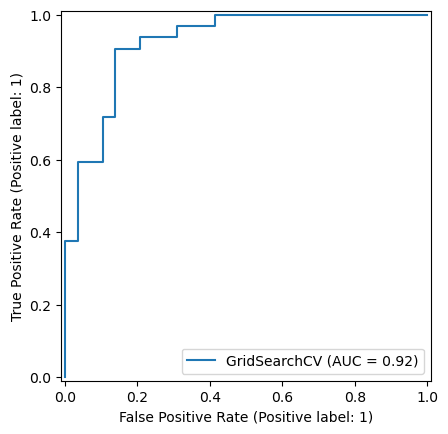

In [123]:
# Plot ROC curve and Calculate AUC metric

RocCurveDisplay.from_estimator(gs_log_reg, X_test, y_test)

In [124]:
# Confusion Matrix
print(confusion_matrix(y_test, y_preds))

[[25  4]
 [ 3 29]]


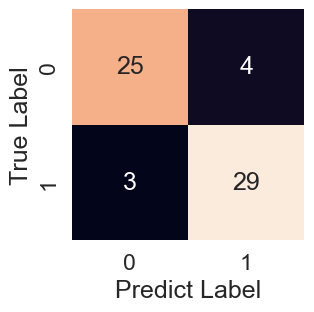

In [ ]:
sns.set_theme(font_scale=1.5)

def plot_conf_mat(y_test, y_pred):
    """
    Plots a nice looking confusion matrix using Seaborn's heatmap()
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_pred),
                     annot=True,
                     cbar=False)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    
        
plot_conf_mat(y_test, y_preds)

- TN -> 25
- FP -> 4
  
- FN -> 3
- TP -> 29

Now we've got a `ROC curve`, an `AUC matric` and a `confusion matrix`, lets's get a `classification report` as well as `Cross-validated precision`, `recall` and `f1-score`.

In [129]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



### **Calculate evaluation matrics using cross-validation**

We're going to calculate **accuracy**, **precison**, **recall**, **f1-score** of our model using **cross-validation** and to do so we'll be using `cross_val_score`

In [130]:
# Chest best hyperparameter

gs_log_reg.best_params_

{'C': np.float64(0.2252986662223231), 'max_iter': 1000, 'solver': 'liblinear'}

In [131]:
# Create a new classifier with best parameters
clf = LogisticRegression(C=np.float64(0.2252986662223231),
                         max_iter=1000,
                         solver="liblinear")

In [143]:
# Cross-validated Accuracy

cv_acc = cross_val_score(clf,
                         X,
                         y,
                         cv=5,
                         scoring="accuracy")
cv_acc = np.mean(cv_acc)
cv_acc

np.float64(0.8479781420765027)

In [142]:
# Cross-validated Precision
cv_precision = cross_val_score(clf,
                         X,
                         y,
                         cv=5,
                         scoring="precision")
cv_precision = np.mean(cv_precision)
cv_precision

np.float64(0.8215873015873015)

In [139]:
# Cross-validated Recall
cv_recall = cross_val_score(clf,
                         X,
                         y,
                         cv=5,
                         scoring="recall")
cv_recall = cv_recall.mean()
cv_recall

np.float64(0.9272727272727274)

In [141]:
# Cross-validated F1-score
cv_f1_score = cross_val_score(clf,
                         X,
                         y,
                         cv=5,
                         scoring="f1")
cv_f1_score = cv_f1_score.mean()
cv_f1_score

np.float64(0.8705403543192143)

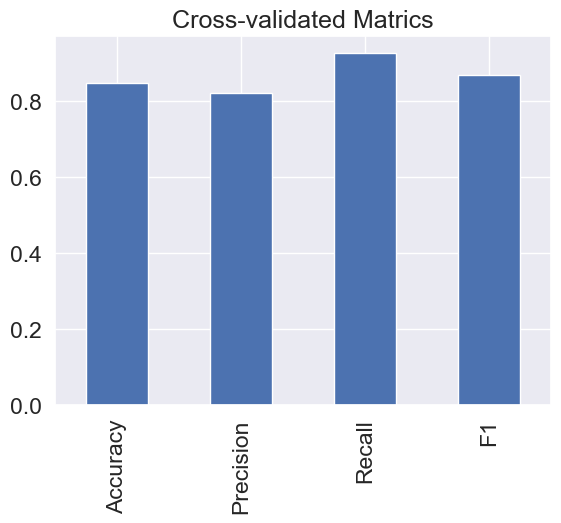

In [153]:
# Visualize cross-validated matrics
cv_metrics = pd.DataFrame({"Accuracy" : cv_acc,
                           "Precision" : cv_precision,
                           "Recall" : cv_recall,
                           "F1" : cv_f1_score},
                          index=[0])
cv_metrics.T.plot.bar(title="Cross-validated Matrics",
                      legend=False);

## **Feature Importance**

Feature importance is another way of asking, **"which features contributed most to the outcomes of the model and how did they contribute?"**


Finding feature importance is different for each machine learning model. One way to find feature imporatnce is to search for `"(MODEL NAME) feature importance"`.

Let's find the feature importance for our `LogesticRegression` Model

In [154]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [156]:
# Fit and instance of LogesticRegression
gs_log_reg.best_params_

clf = LogisticRegression(C=gs_log_reg.best_params_["C"],
                         max_iter=gs_log_reg.best_params_["max_iter"],
                         solver=gs_log_reg.best_params_["solver"])

clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(0.2252986662223231)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class o

In [158]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
# Check coef_ (How much each features contribute towards our target varibale)
clf.coef_

array([[ 0.00356527, -0.89432185,  0.6711084 , -0.01159261, -0.00169676,
         0.04758035,  0.32740779,  0.02470683, -0.62475005, -0.57370411,
         0.46560987, -0.64694399, -0.69199314]])

**clf.coef_  →  only has weights for whatever was in X, because it was trained on X and y seperately**

In [159]:
# match coef's of teh feature to the colomn
feature_dict = dict(zip(df.columns, list(clf.coef_[0])))
feature_dict

{'age': np.float64(0.0035652741293398203),
 'sex': np.float64(-0.8943218485392996),
 'cp': np.float64(0.6711083981472525),
 'trestbps': np.float64(-0.011592612687069145),
 'chol': np.float64(-0.0016967620279860025),
 'fbs': np.float64(0.04758034790392176),
 'restecg': np.float64(0.3274077874512936),
 'thalach': np.float64(0.024706831019072506),
 'exang': np.float64(-0.6247500526574244),
 'oldpeak': np.float64(-0.5737041098177907),
 'slope': np.float64(0.46560986854098657),
 'ca': np.float64(-0.6469439876148974),
 'thal': np.float64(-0.6919931391581186)}

### **Note**

- Positive coef  →  this feature pushes toward heart disease
- Negative coef  →  this feature pushes away from heart disease
- Larger number  →  stronger influence

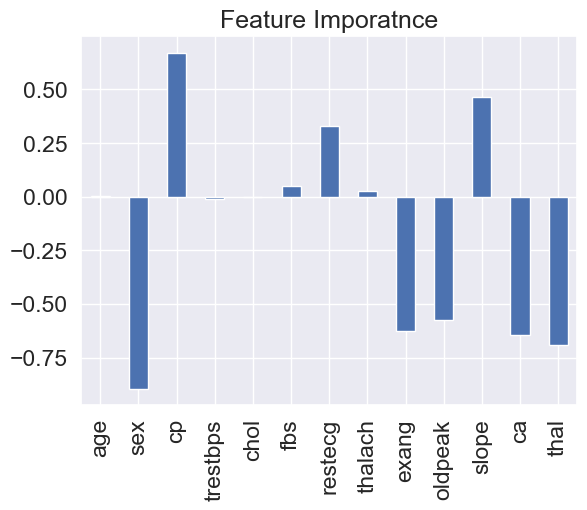

In [165]:
# Visualize Feature importance
feature_df = pd.DataFrame(feature_dict, index=[0])
feature_df.T.plot.bar(title="Feature Imporatnce",
                      legend=False);

### **Note**

- Positive coef  →  this feature pushes toward heart disease
- Negative coef  →  this feature pushes away from heart disease
- Larger number  →  stronger influence


- **`df.corr()`    →  each feature vs target, one at a time, raw data**
- **`clf.coef_`    →  all features together, after model has seen their combined effect**

**`clf.coef_` is smarter — it accounts for how features interact with each other. `df.corr()` looks at each feature in isolation.**

In [167]:
pd.crosstab(df.sex, df.target)

target,0,1
sex,,
0,24,72
1,114,93


**look at the ratio between 0 and 1**

In [168]:
pd.crosstab(df.slope, df.target)

target,0,1
slope,,
0,12,9
1,91,49
2,35,107


`slope` - the slope of the peak exercise ST segment

- `0`: **Upsloping**: better heart rate with excercise (uncommon)
- `1`: **Flatsloping**: minimal change (typical healthy heart)
- `2`: **Downslopins**: signs of unhealthy heart

## **Experimentation**

If you haven't hit your evaluation metric yet... ask yourself...

- Could you collect more data?
- Could you try a better model? Like CatBoost or XGBoost?
- Could you improve the current models? (beyond what we've done so far)
- If your model is good enough (you have hit your evaluation metric) how would you export it and share it with others?

In [172]:
from joblib import dump
dump(gs_log_reg, open("Heart-Disease-LR-Model", "wb"))